# Упражнение 1: Основные операции с тензорами
Цель: Понять и выполнять базовые операции с тензорами в PyTorch. Инструкции: Создайте случайный тензор формы (3, 4) и выведите его.
Выполните следующие операции:
Измените форму тензора на (4, 3).
Вычислите среднее значение и стандартное отклонение тензора.
Выполните матричное умножение с другим тензором формы (4, 2).

In [ ]:
import torch

tensor = torch.rand(3, 4)
print(tensor)

tensor([[0.9974, 0.0537, 0.1058, 0.6066],
        [0.5901, 0.0136, 0.9091, 0.6410],
        [0.3559, 0.9027, 0.0213, 0.3960]])


In [ ]:
reshape= tensor.view(4, 3)
print(reshape)


tensor([[0.9974, 0.0537, 0.1058],
        [0.6066, 0.5901, 0.0136],
        [0.9091, 0.6410, 0.3559],
        [0.9027, 0.0213, 0.3960]])


In [ ]:
meann = tensor.mean()
stdd = tensor.std()
print("\nСреднее значение:", meann.item())
print("Стандартное отклонение:", stdd.item())


Среднее значение: 0.4660986363887787
Стандартное отклонение: 0.36360836029052734


In [ ]:
tensor2 = torch.rand(3, 2)
res = torch.matmul(reshape, tensor2)
print(res)

tensor([[0.7637, 0.3120],
        [0.8126, 0.3625],
        [1.2688, 0.7045],
        [0.8669, 0.4988]])


# Упражнение 2: Реализация простой нейронной сети
Цель: Построить и обучить простую искусственную нейронную сеть с использованием PyTorch. Инструкции:
Используйте модуль nn PyTorch для создания сети прямого распространения с одним скрытым слоем. Размер входного слоя: 10
Размер скрытого слоя: 5
Размер выходного слоя: 1
Используйте синтетический набор данных (создайте случайные входные данные и соответствующие метки) для обучения вашей модели.
Реализуйте цикл обучения с использованием градиентного спуска для минимизации потерь среднеквадратичной ошибки.
Выведите конечные потери после обучения.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

X = torch.rand(100, 10)
y = torch.rand(100, 1)

In [ ]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.hidden = nn.Linear(10, 5)
        self.output = nn.Linear(5, 1)
        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.activation(self.hidden(x))
        x = self.output(x)
        return x

model = SimpleNN()

criterion = nn.MSELoss()  # Среднеквадратичная ошибка
optimizer = optim.SGD(model.parameters(), lr=0.01)

epochs = 10
for epoch in range(epochs):
    predictions = model(X)
    loss = criterion(predictions, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Эпоха {epoch + 1}, Потери: {loss.item():.4f}")

print("\nКонечные потери", loss.item())


Эпоха 1, Потери: 0.1254
Эпоха 2, Потери: 0.1236
Эпоха 3, Потери: 0.1219
Эпоха 4, Потери: 0.1204
Эпоха 5, Потери: 0.1189
Эпоха 6, Потери: 0.1175
Эпоха 7, Потери: 0.1163
Эпоха 8, Потери: 0.1151
Эпоха 9, Потери: 0.1140
Эпоха 10, Потери: 0.1129

Конечные потери 0.1129315197467804


# Упражнение 3: Визуализация градиентного спуска
Цель: Визуализировать процесс градиентного спуска. Инструкции:
Создайте простую модель линейной регрессии с использованием PyTorch.
Сгенерируйте синтетические точки данных, которые следуют линейной зависимости с некоторым шумом. Обучите свою модель с использованием градиентного спуска и зафиксируйте потери на каждой итерации. Постройте график потерь по итерациям, чтобы визуализировать, как они уменьшаются по мере обучения.

Эпоха 50/200, Потери: 3.8197
Эпоха 100/200, Потери: 3.8189
Эпоха 150/200, Потери: 3.8185
Эпоха 200/200, Потери: 3.8182


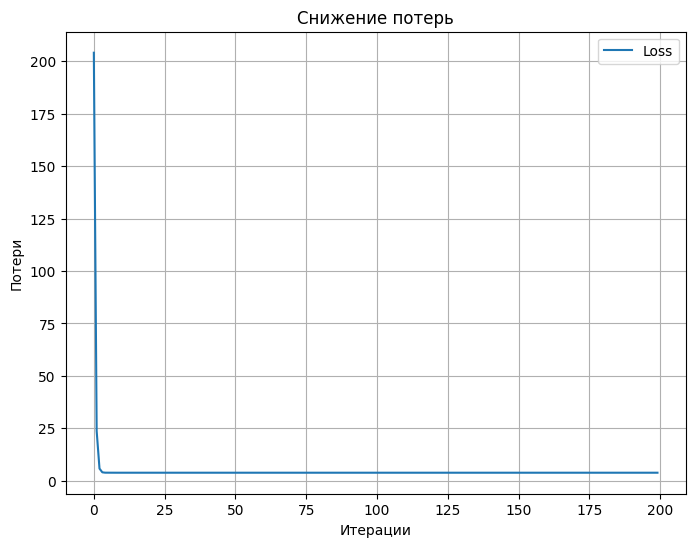

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


X = torch.linspace(0, 10, 100).view(-1, 1)
true_slope = 2.0
true_intercept = 1.0
noise = torch.randn(100, 1) * 2.0
y = true_slope * X + true_intercept + noise

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

model = LinearRegressionModel()

criterion = nn.MSELoss()  # Среднеквадратичная ошибка
optimizer = optim.SGD(model.parameters(), lr=0.01)  # Градиентный спуск

epochs = 200
losses = []

for epoch in range(epochs):
    predictions = model(X)
    loss = criterion(predictions, y)

    losses.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        print(f"Эпоха {epoch + 1}/{epochs}, Потери: {loss.item():.4f}")

plt.figure(figsize=(8, 6))
plt.plot(range(epochs), losses, label='Loss')
plt.xlabel('Итерации')
plt.ylabel('Потери')
plt.title('Снижение потерь')
plt.legend()
plt.grid(True)
plt.show()

# Упражнение 4: Создание CNN для классификации изображений
Цель: Реализовать свёрточную нейронную сеть для классификации изображений.
Инструкции:
Используйте набор данных CIFAR-10, предоставленный PyTorch.
Постройте архитектуру CNN с:
Двумя свёрточными слоями, за которыми следуют активация ReLU и подвыборка.
Полносвязным слоем для классификации.
Обучите вашу CNN на наборе данных CIFAR-10 и оцените её точность на тестовом наборе.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)  # Свёрточный слой 1
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # Свёрточный слой 2
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # Подвыборка
        self.fc1 = nn.Linear(64 * 8 * 8, 128)  # Полносвязный слой
        self.fc2 = nn.Linear(128, 10)  # Выходной слой (10 классов)
        self.relu = nn.ReLU()  # Активация ReLU
        self.dropout = nn.Dropout(0.5)  # Dropout для регуляризации

    def forward(self, x):
        x = self.relu(self.conv1(x))  # Свёртка -> ReLU
        x = self.pool(x)  # Подвыборка
        x = self.relu(self.conv2(x))  # Свёртка -> ReLU
        x = self.pool(x)  # Подвыборка
        x = x.view(-1, 64 * 8 * 8)  # Преобразование в вектор
        x = self.relu(self.fc1(x))  # Полносвязный слой -> ReLU
        x = self.dropout(x)  # Dropout
        x = self.fc2(x)  # Выходной слой
        return x

model = CNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Эпоха {epoch + 1}/{epochs}, Потери: {running_loss / len(train_loader):.4f}")

model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Точность: {accuracy:.2f}%")


100%|██████████| 170M/170M [00:01<00:00, 95.4MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified
Эпоха 1/10, Потери: 1.5167
Эпоха 2/10, Потери: 1.1821
Эпоха 3/10, Потери: 1.0638
Эпоха 4/10, Потери: 0.9734
Эпоха 5/10, Потери: 0.9109
Эпоха 6/10, Потери: 0.8556
Эпоха 7/10, Потери: 0.8023
Эпоха 8/10, Потери: 0.7599
Эпоха 9/10, Потери: 0.7213
Эпоха 10/10, Потери: 0.6811
Точность: 71.87%


# Упражнение 5: Реализация RNN для предсказания последовательностей
Цель: Построить и обучить рекуррентную нейронную сеть для задач предсказания последовательностей.
Инструкции:
	Создайте синтетический набор данных, представляющий последовательности (например, значения синусоиды).
	Постройте модель РНС, используя модуль nn.RNN PyTorch, для предсказания будущих значений в последовательности.
	Обучите вашу РНС на этом наборе данных и визуализируйте предсказания по сравнению с фактическими значениями.


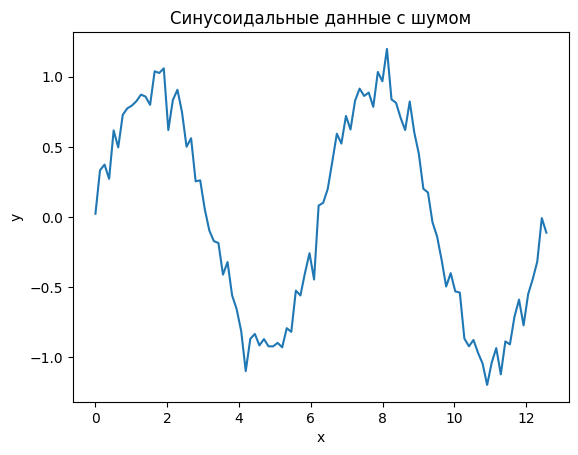

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt


def generate_data(seq_length):
    x = np.linspace(0, 4 * np.pi, seq_length)
    y = np.sin(x) + 0.1 * np.random.randn(seq_length)
    return x, y

seq_length = 100
x, y = generate_data(seq_length)

plt.plot(x, y)
plt.title('Синусоидальные данные с шумом')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


In [ ]:
import torch.nn as nn
import torch.optim as optim

input_size = 1
hidden_size = 32
output_size = 1
num_layers = 1

class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out


In [ ]:
def create_sequences(data, seq_length=10):
    x_seq = []
    y_seq = []
    for i in range(len(data) - seq_length):
        x_seq.append(data[i:i+seq_length])
        y_seq.append(data[i+seq_length])
    return np.array(x_seq), np.array(y_seq)


seq_length = 10
x_seq, y_seq = create_sequences(y, seq_length)

x_seq = torch.Tensor(x_seq).unsqueeze(-1)
y_seq = torch.Tensor(y_seq).unsqueeze(-1)


In [ ]:
model = RNNModel(input_size, hidden_size, output_size, num_layers)
criterion = nn.MSELoss()  # Среднеквадратичная ошибка
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 200
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x_seq)  # Прогнозируем
    loss = criterion(outputs, y_seq)  # Вычисляем потери
    loss.backward()  # Обратный проход
    optimizer.step()  # Обновление параметров

    if (epoch+1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')


Epoch [20/200], Loss: 0.3836
Epoch [40/200], Loss: 0.1146
Epoch [60/200], Loss: 0.0450
Epoch [80/200], Loss: 0.0228
Epoch [100/200], Loss: 0.0203
Epoch [120/200], Loss: 0.0197
Epoch [140/200], Loss: 0.0194
Epoch [160/200], Loss: 0.0191
Epoch [180/200], Loss: 0.0188
Epoch [200/200], Loss: 0.0186


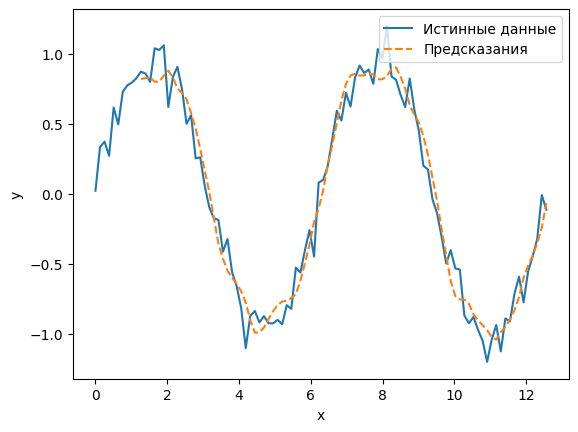

In [ ]:
model.eval()
with torch.no_grad():
    predicted = model(x_seq).detach().numpy()

plt.plot(x, y, label='Истинные данные')
plt.plot(x[seq_length:], predicted, label='Предсказания', linestyle='dashed')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.show()


# Упражнение 6: Использование LSTM для прогнозирования временных рядов
Цель: Реализовать сеть LSTM для прогнозирования временных рядов.
Инструкции:
	Сгенерируйте набор данных временных рядов (например, цены акций или показания температуры).
	Постройте модель LSTM, используя модуль nn.LSTM PyTorch, для предсказания будущих значений на основе прошлых наблюдений.
	Обучите вашу модель LSTM и оцените её производительность на валидационном наборе.
	Постройте график предсказанных значений по сравнению с фактическими и обсудите результаты, сосредоточившись на том, как LSTM справляются с долгосрочными зависимостями в данных (150-200 слов).


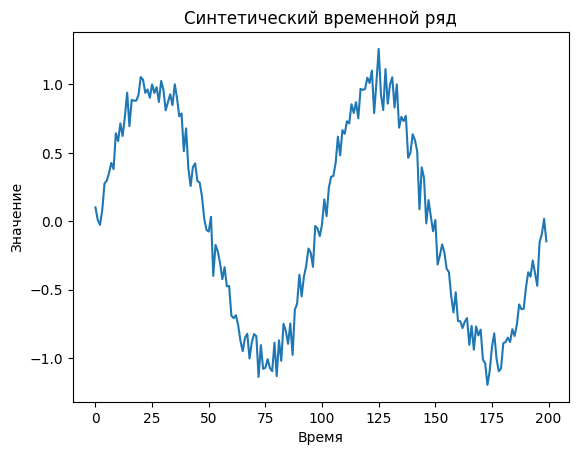

Epoch [20/100], Loss: 0.1843
Epoch [40/100], Loss: 0.0732
Epoch [60/100], Loss: 0.0536
Epoch [80/100], Loss: 0.0353
Epoch [100/100], Loss: 0.0188


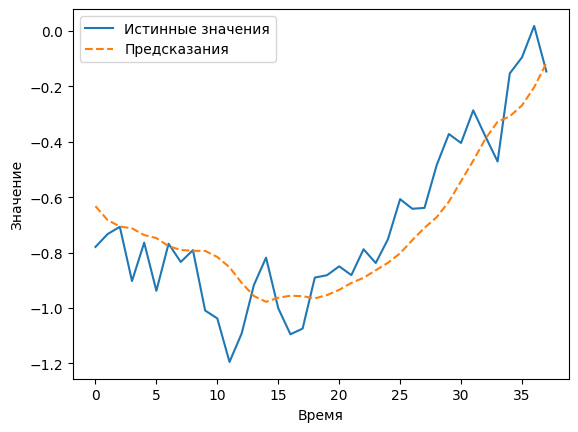

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

def generate_time_series(seq_length):
    x = np.linspace(0, 4 * np.pi, seq_length)
    y = np.sin(x) + 0.1 * np.random.randn(seq_length)
    return y

seq_length = 200
y = generate_time_series(seq_length)

plt.plot(y)
plt.title('Синтетический временной ряд')
plt.xlabel('Время')
plt.ylabel('Значение')
plt.show()

def create_sequences(data, seq_length=10):
    x_seq = []
    y_seq = []
    for i in range(len(data) - seq_length):
        x_seq.append(data[i:i+seq_length]) # Входные последовательности
        y_seq.append(data[i+seq_length])  # Выходные (следующие значения)
    return np.array(x_seq), np.array(y_seq)

seq_length = 10
x_seq, y_seq = create_sequences(y, seq_length)

x_seq = torch.Tensor(x_seq).unsqueeze(-1)
y_seq = torch.Tensor(y_seq).unsqueeze(-1)

train_size = int(len(x_seq) * 0.8)
x_train, y_train = x_seq[:train_size], y_seq[:train_size]
x_val, y_val = x_seq[train_size:], y_seq[train_size:]

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

input_size = 1
hidden_size = 64
output_size = 1
num_layers = 2

model = LSTMModel(input_size, hidden_size, output_size, num_layers)
criterion = nn.MSELoss()  # Среднеквадратичная ошибка
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 100
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x_train)  # Прогнозируем
    loss = criterion(outputs, y_train)  # Вычисляем потери
    loss.backward()  # Обратный проход
    optimizer.step()  # Обновление параметров

    if (epoch+1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

model.eval()
with torch.no_grad():
    predicted = model(x_val).detach().numpy()

plt.plot(np.arange(len(y_val)), y_val, label='Истинные значения')
plt.plot(np.arange(len(predicted)), predicted, label='Предсказания', linestyle='dashed')
plt.legend()
plt.xlabel('Время')
plt.ylabel('Значение')
plt.show()


# Упражнение 7: Настройка гиперпараметров
Цель: Экспериментировать с различными гиперпараметрами в ваших моделях.
Инструкции:
	Выберите одну из ранее реализованных моделей (ИНС, СКС, РНС или LSTM).
	Экспериментируйте с различными гиперпараметрами, такими как скорость обучения, размер пакета, число эпох или количество слоев/нейронов.
	Документируйте, как изменения этих гиперпараметров влияют на показатели производительности модели, такие как точность или потери.


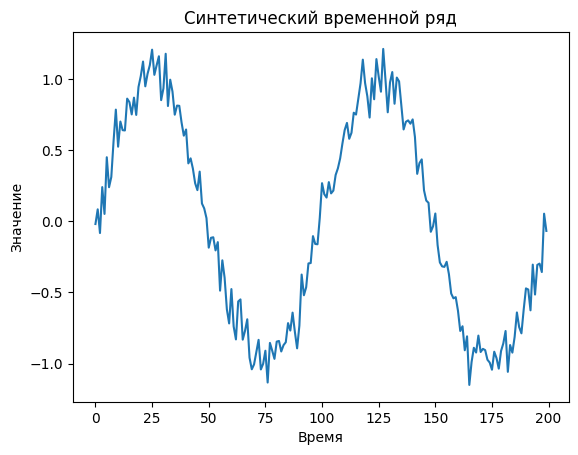

Epoch [10/100], Loss: 0.0454
Epoch [20/100], Loss: 0.0306
Epoch [30/100], Loss: 0.0123
Epoch [40/100], Loss: 0.0179
Epoch [50/100], Loss: 0.0199
Epoch [60/100], Loss: 0.0208
Epoch [70/100], Loss: 0.0189
Epoch [80/100], Loss: 0.0194
Epoch [90/100], Loss: 0.0147
Epoch [100/100], Loss: 0.0162


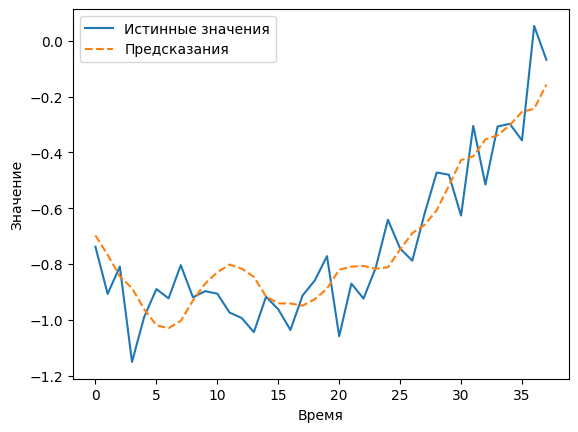

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
def generate_time_series(seq_length):
    x = np.linspace(0, 4 * np.pi, seq_length)
    y = np.sin(x) + 0.1 * np.random.randn(seq_length)  # Добавление шума
    return y

seq_length = 200
y = generate_time_series(seq_length)

plt.plot(y)
plt.title('Синтетический временной ряд')
plt.xlabel('Время')
plt.ylabel('Значение')
plt.show()

def create_sequences(data, seq_length=10):
    x_seq = []
    y_seq = []
    for i in range(len(data) - seq_length):
        x_seq.append(data[i:i+seq_length])
        y_seq.append(data[i+seq_length])
    return np.array(x_seq), np.array(y_seq)


seq_length = 10
x_seq, y_seq = create_sequences(y, seq_length)

# Преобразуем в тензоры
x_seq = torch.Tensor(x_seq).unsqueeze(-1)
y_seq = torch.Tensor(y_seq).unsqueeze(-1)


train_size = int(len(x_seq) * 0.8)
x_train, y_train = x_seq[:train_size], y_seq[:train_size]
x_val, y_val = x_seq[train_size:], y_seq[train_size:]

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

# Настройка гиперпараметров
learning_rate = 0.001  # Скорость обучения
batch_size = 32  # Размер пакета
epochs = 100  # Число эпох
hidden_size = 64  # Размер скрытого слоя
num_layers = 2  # Число слоев LSTM


model = LSTMModel(input_size=1, hidden_size=hidden_size, output_size=1, num_layers=num_layers)
criterion = nn.MSELoss()  # Среднеквадратичная ошибка
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

train_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(x_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(x_val, y_val), batch_size=batch_size, shuffle=False)

# Обучение модели
for epoch in range(epochs):
    model.train()
    for i, (inputs, targets) in enumerate(train_loader):
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')


model.eval()
with torch.no_grad():
    predicted = model(x_val).detach().numpy()

plt.plot(np.arange(len(y_val)), y_val, label='Истинные значения')
plt.plot(np.arange(len(predicted)), predicted, label='Предсказания', linestyle='dashed')
plt.legend()
plt.xlabel('Время')
plt.ylabel('Значение')
plt.show()
